In [7]:
import torch
import matplotlib.pyplot as plt
import io
import math
import random
from PIL import Image


In [2]:
imagenet_msglen4_iter0 = torch.load("msgs/imagenet_msglen4_iter0.pt")
imagenet_msglen4_iter50 = torch.load("msgs/imagenet_msglen4_iter50.pt")
imagenet_msglen5_iter100 = torch.load("msgs/imagenet_msglen5_iter100.pt")

mnist1_msglen9_iter200 = torch.load("msgs/mnist1_msglen9_iter200.pt")
mnist1_msglen4_iter0 = torch.load("msgs/mnist1_msglen4_iter0.pt")

shape1_msglen4_iter0 = torch.load("msgs/shape1_msglen4_iter0.pt")
shape1_msglen9_iter200 = torch.load("msgs/shape1_msglen9_iter200.pt")

In [3]:
import glob
import pandas as pd

files = sorted(glob.glob("/home/shared/data/imagenet/validation-*.parquet"))

df = pd.read_parquet(files)

In [4]:
def show_imgnet(idx, df=df, title=None):
    img_bytes = df.loc[idx, 'image']['bytes']
    img = Image.open(io.BytesIO(img_bytes))

    plt.imshow(img)
    plt.axis("off")
    if title != None:
        plt.title(title)

def show_img(img, title=None):
    img = img.squeeze()

    plt.imshow(img, cmap='gray')
    if title != None:
        plt.title(title)
    plt.axis('off')


In [9]:
def get_knn(msgs, query_idx, k=5, batch_size=32, in_batch=False, dataset='imagenet'):
    
    if in_batch:
        start = batch_size * (query_idx // batch_size)
        end = start + batch_size
        query_idx = query_idx % batch_size
    else:
        start = 0
        end = len(msgs["words"])
        
    words = msgs["words"][start:end]
    query = words[query_idx]

    msg_dist = (words != query).sum(dim=-1)

    # exclude self
    msg_dist[query_idx] = 100

    knn = torch.topk(msg_dist, k, largest=False)
    
    nearest_idxs = knn.indices
    
    if True:
        rows = math.ceil(k / 5)

        fig, axes = plt.subplots(rows, 5, figsize=(15, rows * 3))

        axes = axes.flatten()

        for ax, idx, dist in zip(axes, nearest_idxs, knn.values):
            plt.sca(ax)
            if dataset == 'imagenet':
                show_imgnet(msgs['indices'][start:end][idx].item(), title=f"Dist: {dist.item()} - Msg: {words[idx].tolist()}")
            else:
                show_img(msgs['imgs'][start:end][idx], title=f"{dist.item()}")

        # hide unused subplots
        for ax in axes[len(nearest_idxs):]:
            ax.axis("off")

        plt.tight_layout()
        plt.show()

    return knn
    

## Imagenet

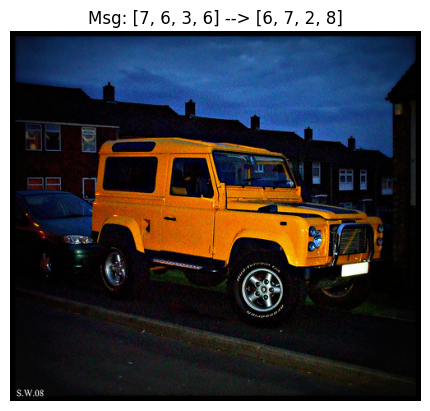

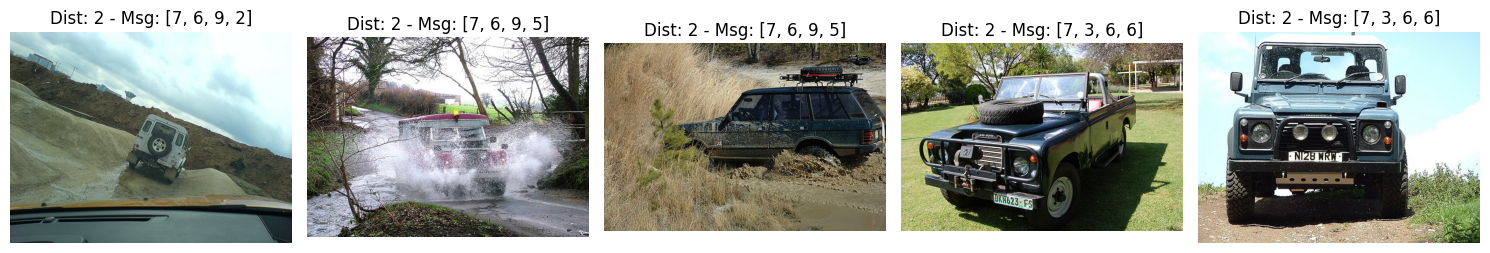

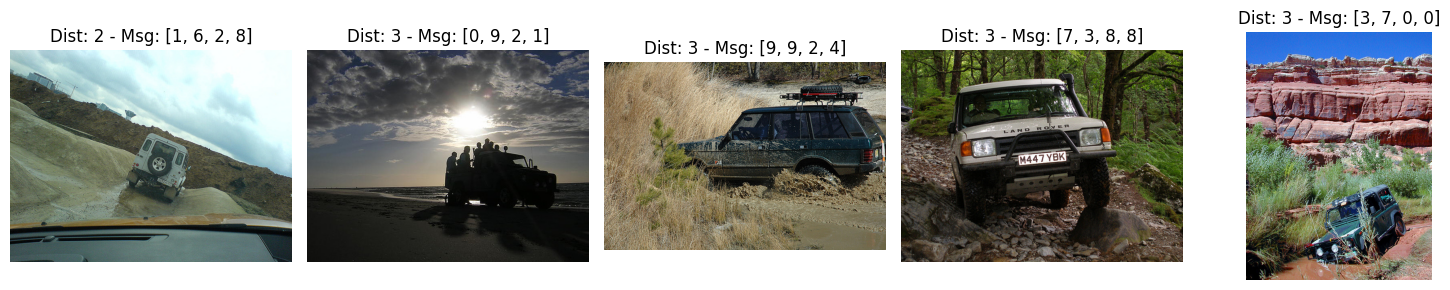

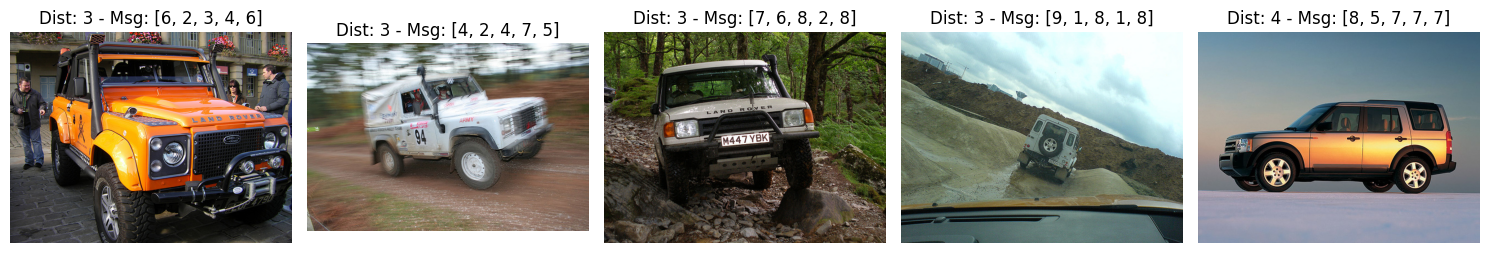

In [ ]:
idx = random.randint(0, 1600) # 146

show_imgnet(imagenet_msglen4_iter0['indices'][idx].item(), title=f"Msg: {imagenet_msglen4_iter0['words'][idx].tolist()} --> {imagenet_msglen4_iter50['words'][idx].tolist()}")

in_batch = True
get_knn(imagenet_msglen4_iter0, idx, in_batch=in_batch)
get_knn(imagenet_msglen4_iter50, idx, in_batch=in_batch)
get_knn(imagenet_msglen5_iter100, idx, in_batch=in_batch);

## MNIST

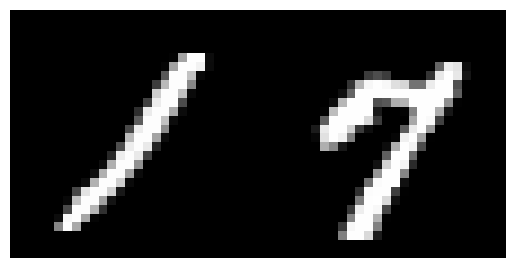

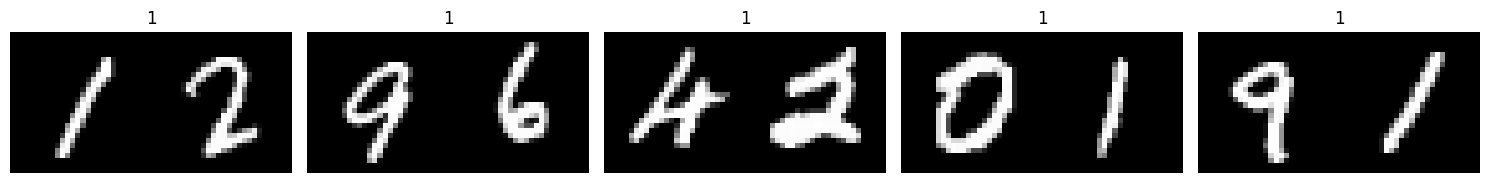

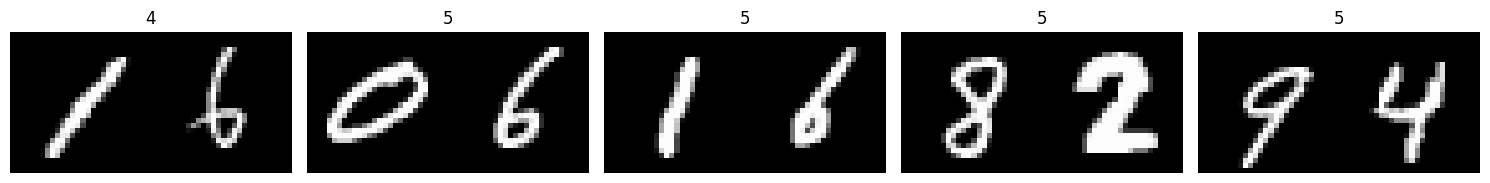

torch.return_types.topk(
values=tensor([4, 5, 5, 5, 5]),
indices=tensor([1298,  623,  338,  296,  629]))

In [ ]:
idx = random.randint(0, 2000)

show_img(mnist1_msglen9_iter200['imgs'][idx])

in_batch = False
get_knn(mnist1_msglen4_iter0, idx, dataset="mnist", in_batch=in_batch, batch_size=100)
get_knn(mnist1_msglen9_iter200, idx, dataset="mnist", in_batch=in_batch, batch_size=100);

## Shape

In [ ]:
idx = random.randint(0, 2000) # 45, 864

show_img(shape1_msglen4_iter0['imgs'][idx])

get_knn(shape1_msglen9_iter200, idx, k = 5)
get_knn(shape1_msglen4_iter0, idx, k = 5)